In [1]:
import pandas as pd
import numpy as np
import random
from tableshift import get_dataset
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
import pickle
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
from scipy.stats import rankdata
from scipy import stats as st
from matplotlib.ticker import FormatStrFormatter
from sklearn.preprocessing import StandardScaler

In [2]:
## The below data pulls in nhanes cholesterol data from tableshift package.
## Before doing so, you need to comment out in the soure code the line that binarizes the target in the nhanes.py file
## to do the regression task. This corresponds to lines 323-324 in the preprocess_nhanes_cholesterol function
# # Binarize the target
# df[target] = (df[target] >= threshold).astype(float)

dataset_name = "nhanes_cholesterol"
# chol_data = get_dataset(dataset_name)
# 
# X_source_chol, y_source_chol, _, _ = chol_data.get_pandas("train")
# X_target_chol, y_target_chol, _, _ = chol_data.get_pandas("ood_validation")
# X_target_chol_test, y_target_chol_test, _, _ = chol_data.get_pandas("ood_test")
# 
# pd.concat([X_source_chol, X_target_chol, X_target_chol_test], axis=1).to_csv(f"data/{dataset_name}_X_tableshift.csv", index=False)
# pd.concat([y_source_chol, y_target_chol, y_target_chol_test], axis=1).to_csv(f"data/{dataset_name}_y_tableshift.csv", index=False)


In [3]:

X = pd.read_csv(f"data/{dataset_name}_X_tableshift.csv")
y = pd.read_csv(f"data/{dataset_name}_y_tableshift.csv")
X = pd.concat([X,y], axis=1).reset_index(drop=True)
response = 'LBDLDL'

target = 2017

## Dataset 1: 
X1 = (X[X.nhanes_year.isin([2013, 2015]) & (X.RIAGENDR == 0) & (X.RIDRETH_merged == 1)]
      .drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged'])
      .reset_index(drop=True))

## Dataset 2: 
X2 = (X[X.nhanes_year.isin([1999, 2001, 2003, 2015])]
      .drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged'])
      .reset_index(drop=True))

## Dataset 3: 
X3 = (X[X.nhanes_year.isin([2013, 2015]) & (X.RIDRETH_merged == 1) & (X.RIAGENDR == 1)]
      .drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged'])
      .reset_index(drop=True))

## Dataset 4: 
X4 = (X[(X.nhanes_year == 2011) & (X.RIAGENDR == 1)]
      .drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged'])
      .reset_index(drop=True))

## Dataset 5: 
X5 = (X[(X.nhanes_year.isin([1999, 2015]) & (X.RIAGENDR == 0) & (X.RIDRETH_merged == 0)) |
        (X.nhanes_year.isin([2000, 2015]) & (X.RIAGENDR == 1) & (X.RIDRETH_merged == 0))]
      .drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged'])
      .reset_index(drop=True))

## Dataset 6: 
X6 = (X[X.nhanes_year.isin([1999, 2005, 2013])]
      .drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged'])
      .reset_index(drop=True))

## Helper function
def scale_dataset(X):
    scaler = StandardScaler(with_mean=False)
    return pd.DataFrame(
        scaler.fit_transform(X),
        index=X.index,
        columns=X.columns
    )

# Scale each dataset independently, overwrite original X_k
dataset_ids = list(range(1,7))
X1 = scale_dataset(X1)
X2 = scale_dataset(X2)
X3 = scale_dataset(X3)
X4 = scale_dataset(X4)
X5 = scale_dataset(X5)
X6 = scale_dataset(X6)

# GLOBAL CONSTANTS 
target_X = X[X.nhanes_year == 2017].drop(columns=['nhanes_year', 'RIAGENDR', 'RIDRETH_merged']).reset_index(drop=True)
target_X = scale_dataset(target_X)
TARGET_COV = np.mean(target_X.drop(columns=[response]), axis=0)

print(target_X.shape, X1.shape, X2.shape, X3.shape, X4.shape, X5.shape, X6.shape)

(2808, 52) (1095, 52) (13131, 52) (1069, 52) (1455, 52) (1492, 52) (9302, 52)


In [4]:
EPS = 1e-6 

def compute_pca(X1, X2, random_state=None):
    """First reduce dimensions"""
    # Project to PCA with fixed seed
    pipeline = make_pipeline(
        StandardScaler(), 
        PCA(n_components=3, random_state=random_state)
    )
    combined = pd.concat([X1, X2], axis=0).sort_index()
    pipeline.fit(combined)

    X1_proj = pipeline.transform(X1)
    X2_proj = pipeline.transform(X2)
    return X1_proj, X2_proj
    
def fit_density(X, bandwidths=np.logspace(-1, 1, 20)):
    """Fit a KDE with bandwidth selection."""
    grid = GridSearchCV(
        KernelDensity(kernel="gaussian"),
        {"bandwidth": bandwidths},
        cv=5,
        n_jobs=1,
    )
    grid.fit(X)
    return grid.best_estimator_

def compute_kl(X1, X2, random_state=None):
    """
    Compute KL(Target||Source) using KDE estimates.
    X1: samples from Target
    X2: samples from Source
    """
    # PCA projection
    X1_pca, X2_pca = compute_pca(X1, X2, random_state=random_state)

    # Fit KDEs
    kde_t = fit_density(X1_pca)
    kde_s = fit_density(X2_pca)

    # Evaluate densities at X1 points
    t = np.exp(kde_t.score_samples(X1_pca)) + EPS
    s = np.exp(kde_s.score_samples(X1_pca)) + EPS

    t /= t.sum()
    s /= s.sum()

    # KL(Target||Source)
    return st.entropy(t, s)

def compute_score_x(X1, X2, random_state=None):
    """
    Compute mean log-density ratio for X1 relative to X2.
    """
    # PCA projection
    X1_pca, X2_pca = compute_pca(X1, X2, random_state=random_state)
    
    # Fit KDEs
    kde_t = fit_density(X1_pca)
    kde_s = fit_density(X2_pca)

    # Evaluate on combined grid
    log_t = np.log(np.exp(kde_t.score_samples(X1_pca)) + EPS)
    log_s = np.log(np.exp(kde_s.score_samples(X1_pca)) + EPS)

    log_ratio = log_t - log_s
    return np.mean(log_ratio) / np.std(log_ratio)

In [5]:
EPS = 1e-6 

def get_weights(X_source, n_k, y_reg, Xbar_kpt, response, random_state=None):
    """
    Get optimal weights and estimated DUC for NHANES pre-defined datasets.

    :param X_source: list of feature DataFrames [X1, ..., X6] 
    :param n_k: number of source samples
    :param y_reg: E_1[X] - Ehat_target[X]
    :param Xbar_kpt: Ehat_target[X]
    :param response: target column name (for assembling supervised frames)
    :param random_state: seed for reproducibility
    :return: dict of {samples_s (features+label), weights, duc}
    """

    samples_s = X_source.sample(n=n_k, random_state=random_state)
    Xbar_kp = np.mean(samples_s.drop([response],axis=1), axis=0)
    
    # Calc weights
    x_s = Xbar_kp - Xbar_kpt
    weights = LinearRegression(fit_intercept=False).fit(np.array(x_s).reshape(-1, 1), np.array(y_reg).reshape(-1, 1)).coef_[0]
    weights_trunc = pd.Series(weights).apply(lambda x: 1 if x > 1 else x).apply(lambda x: 0 if x < 0 else x)[0] # Make sure weights are between 0,1

    # Estimate DUC
    corr_sq = pearsonr(y_reg,x_s)[0]**2
    var_x = np.var(x_s)
    
    # Correctly calculate it if weights were truncated
    if weights_trunc == 0:
        duc = 0
    elif weights_trunc ==1:
        duc = var_x/np.var(y_reg)
    else:
        duc = corr_sq 
    
    results = {
        'samples_s': samples_s,
        'weights': weights_trunc,
        'duc': duc,
    }
    
    return results

def run_experiment_nhanes(
    target_X, all_sources, n_test, n_k, n_t, response, random_state=None, 
):
    """
    Runs experiment using the six pre-defined NHANES datasets as sources and the target_year=2017 cohort as target.
    
    :param n_test: samples for testing (from target_year)
    :param n_k: samples for each source
    :param n_t: samples for target train
    :param random_state: seed
    :return: results dict (same keys as original)
    """
    n_sources = len(all_sources)
    
    # Set local random state
    if random_state is not None:
        np.random.seed(random_state)
        random.seed(random_state)

    # Calculate E_target[phi] - use random_state for sampling
    if random_state is not None:
        random.seed(random_state)
        
    test_indices = random.sample(target_X.index.tolist(), n_test)
    samples_test = target_X[target_X.index.isin(test_indices)]
    target_X_new = target_X.drop(test_indices, axis=0)

    # Use global constant TARGET_COV as E_1[X]
    samples_t = target_X_new.sample(n=n_t, random_state=random_state)
    Xbar_kpt = np.mean(samples_t.drop([response],axis=1), axis=0)
    y_reg = TARGET_COV - Xbar_kpt

    # Run all sources with deterministic random states
    source_seeds = [random_state + i if random_state is not None else None for i in range(n_sources)]
    res = [get_weights(X_source, n_k, y_reg, Xbar_kpt, response, random_state=seed) 
           for X_source, seed in zip(all_sources, source_seeds)]

    # Unpack
    samples_list = [res[s].get('samples_s') for s in range(n_sources)]
    weights_list = [res[s].get('weights') for s in range(n_sources)]
    duc_list = [res[s].get('duc') for s in range(n_sources)]
    
    # Calculate KL divergence and score metrics with seeds
    kl_seeds = [random_state + i if random_state is not None else None for i in range(len(samples_list))]
    score_seeds = [random_state + i if random_state is not None else None for i in range(len(samples_list))]
    
    kl = [compute_kl(samples_t.drop([response],axis=1), X2.drop([response],axis=1), random_state=seed) for X2, seed in zip(samples_list, kl_seeds)]
    score_x = [compute_score_x(samples_t.drop([response],axis=1), X2.drop([response],axis=1), random_state=seed) for X2, seed in zip(samples_list, score_seeds)]
    
    ##### comparisons
    # Using target only
    fit_target = RandomForestRegressor(random_state=random_state).fit(
        samples_t.drop([response],axis=1), samples_t[response])
    y_hat_t = fit_target.predict(samples_test.drop([response], axis=1))
    target_mse = np.mean((samples_test[response]-y_hat_t)**2)
    
    # Pooling
    samples_st_list = [pd.concat([samples_s, samples_t]) for samples_s in samples_list]
    rf_seeds = [random_state + i if random_state is not None else None for i in range(len(samples_st_list))]
    y_hat_pool_list = [
        RandomForestRegressor(random_state=seed).fit(
            samples_st.drop([response], axis=1), samples_st[response]
        ).predict(samples_test.drop([response], axis=1)) 
        for samples_st, seed in zip(samples_st_list, rf_seeds)
    ]
    pool_mse_list = [np.mean((samples_test[response]-y_hat_pool)**2) for y_hat_pool in y_hat_pool_list]
    
    # Optimal
    rf_seeds_2 = [random_state + i if random_state is not None else None for i in range(len(samples_list))]
    y_hat_s_list = [
        RandomForestRegressor(random_state=seed).fit(
            samples_s.drop([response], axis=1), samples_s[response]
        ).predict(samples_test.drop([response], axis=1)) 
        for samples_s, seed in zip(samples_list, rf_seeds_2)
    ]
    y_hat_weighted_list = [w*y_hat_s+(1-w)*y_hat_t for w,y_hat_s in zip(weights_list, y_hat_s_list)]
    weighted_mse_list = [np.mean((samples_test[response]-y_hat_weighted)**2) for y_hat_weighted in y_hat_weighted_list]

    
    results = {
        'target_mse': target_mse,
        'pool_mse_list': pool_mse_list,
        'weighted_mse_list': weighted_mse_list,
        'weights_list': weights_list,
        'duc_list': duc_list,
        'kl_list': kl,
        'score_x_list': score_x
    }
    return results

def run_experiment_with_seed(seed, target_X, all_sources, n_test, n_k, n_t, response="LBDLDL"):
    """Run experiment with seed isolation (NHANES, ACS style)."""
    return run_experiment_nhanes(
        target_X, all_sources, n_test, n_k, n_t, random_state=seed, response=response
    )


In [6]:

# Settings
n_t = 30
n_k = 1000
n_test = 1000
trials = 1000
global_seed = 123
np.random.seed(global_seed)
random.seed(global_seed)
trial_seeds = [global_seed + i for i in range(trials)]

all_sources = [X1, X2, X3, X4, X5, X6]
# Run (sequential for determinism with sklearn)
# results = []
# for seed in tqdm(trial_seeds, desc="Running NHANES experiments"):
#     res = run_experiment_with_seed(
#         seed, target_X, all_sources, n_test, n_k, n_t,
#     )
#     results.append(res)

# with open("nhanes_results_chol_123.pkl", "wb") as f:
#     pickle.dump(results, f)


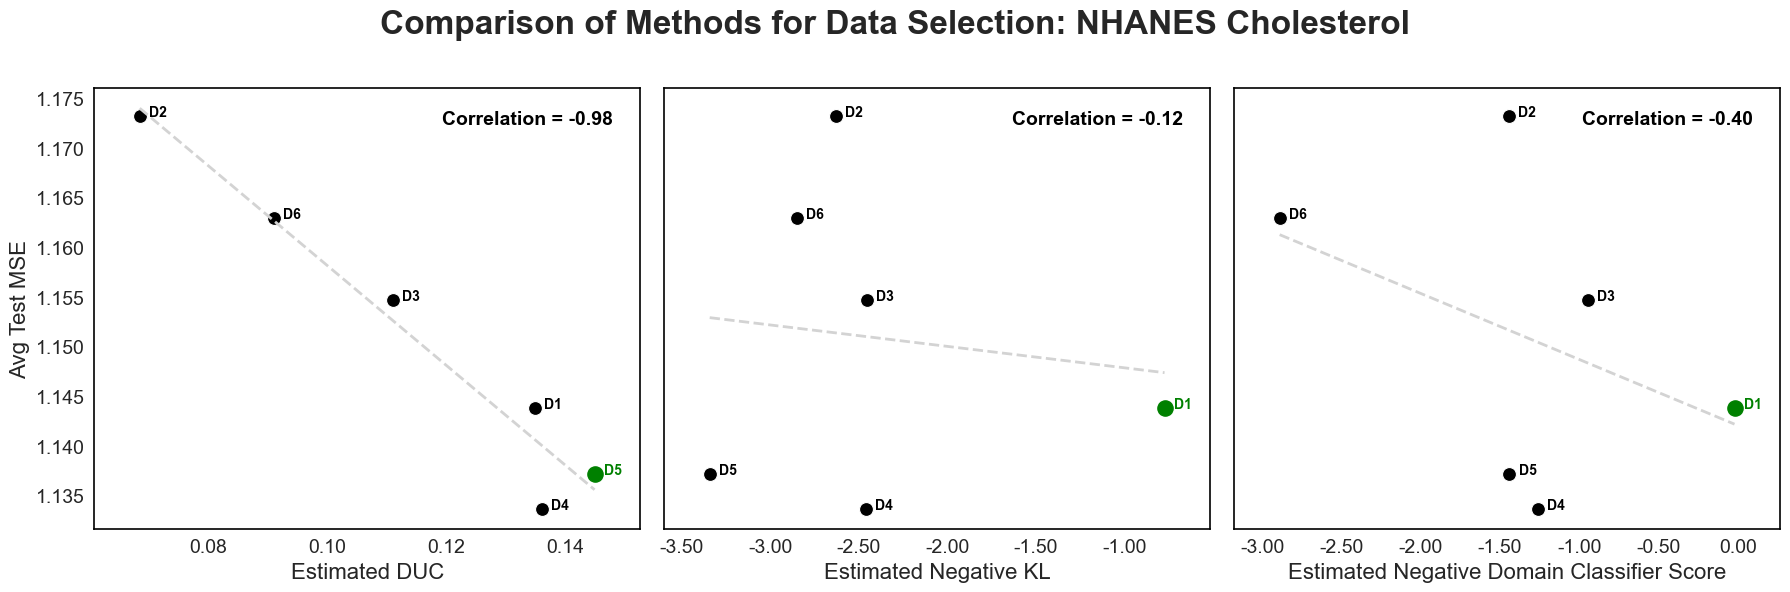

In [7]:

with open("nhanes_results_chol_123.pkl", "rb") as f:  
    results = pickle.load(f)

dataset_labels = ["D1","D2","D3","D4","D5","D6"]  

K = len(dataset_labels)

results_df = pd.DataFrame({
    "label": dataset_labels,
    "weights": [np.mean([r['weights_list'][k] for r in results]) for k in range(K)],
    "pool_mse_list": [np.mean([r['pool_mse_list'][k] for r in results]) for k in range(K)],
    "weighted_mse_list": [np.mean([r['weighted_mse_list'][k] for r in results]) for k in range(K)],
    "weighted_mse_std": [np.std([r['weighted_mse_list'][k] for r in results]) for k in range(K)],
    "duc": [np.mean([r['duc_list'][k] for r in results]) for k in range(K)],
    "neg_kl": [-np.mean([r['kl_list'][k] for r in results]) for k in range(K)],
    "neg_score_x": [-np.mean([r['score_x_list'][k] for r in results]) for k in range(K)],
}).sort_values(by='duc', ascending=False).reset_index(drop=True)

x_columns = ['duc', 'neg_kl', 'neg_score_x']
x_labels = [
    'Estimated DUC',
    'Estimated Negative KL',
    'Estimated Negative Domain Classifier Score'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, facecolor='white')

for ax, x_col, x_label in zip(axes, x_columns, x_labels):
    x_min, x_max = results_df[x_col].min(), results_df[x_col].max()
    x_range = x_max - x_min if x_max > x_min else 1.0

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

    # Mean points
    sns.scatterplot(
        x=x_col,
        y='weighted_mse_list',
        data=results_df,
        s=100,
        color='black',
        ax=ax
    )

    # Highlight the max on this x-axis
    max_idx = results_df[x_col].idxmax()
    ax.scatter(
        results_df.loc[max_idx, x_col],
        results_df.loc[max_idx, 'weighted_mse_list'],
        s=120,
        color='green',
        zorder=3
    )

    # Regression line
    sns.regplot(
        x=x_col,
        y='weighted_mse_list',
        data=results_df,
        scatter=False,
        ax=ax,
        color='blue',
        ci=None,
        line_kws={'color': 'lightgrey', 'linestyle': '--', 'linewidth': 2}
    )

    # Pearson correlation
    corr, _ = pearsonr(results_df[x_col], results_df['weighted_mse_list'])
    ax.text(
        0.95, 0.95, f'Correlation = {corr:.2f}',
        transform=ax.transAxes,
        fontsize=14, va='top', ha='right',
        color='black', weight='bold'
    )

    ax.set_facecolor('white')
    ax.grid(False)

    # Labels near points
    for i in range(results_df.shape[0]):
        color = 'green' if i == max_idx else 'black'
        # small jitter to reduce overlap
        # y_adjustment = (0.002 if (i % 2 == 0) else -0.002) * max(1.0, results_df['weighted_mse_list'].max())
        ax.text(
            results_df[x_col][i] + 0.02 * x_range,
            results_df['weighted_mse_list'][i] ,
            results_df['label'][i], color=color, weight='semibold'
        )

    ax.set_xlim(x_min - 0.1 * x_range, x_max + 0.1 * x_range)
    ax.set_xlabel(x_label, fontsize=16)

    # Style spines
    for spine in ['left', 'bottom', 'top', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.2)

axes[0].set_ylabel('Avg Test MSE', fontsize=16)
plt.suptitle('Comparison of Methods for Data Selection: NHANES Cholesterol', fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [8]:
np.mean([r['target_mse'] for r in results])

1.204919380713674

In [9]:

MSE_TK = np.vstack([np.asarray(r['weighted_mse_list'])[:K].astype(float) for r in results])  

## Helper function to get rank
def ranks_lower_better(vec):
    ranks = np.full_like(vec, np.nan, dtype=float)
    m = np.isfinite(vec)
    if m.sum() >= 1:
        ranks[m] = rankdata(vec[m], method='average')  
    return ranks

R_TK = np.vstack([ranks_lower_better(row) for row in MSE_TK]) 

# get ranks
avg_rank = np.nanmean(R_TK, axis=0)         
rank_df = pd.DataFrame({
    "label": dataset_labels,
    "avg_rank": avg_rank,
})
results_df = results_df.merge(rank_df, on="label", how="left")


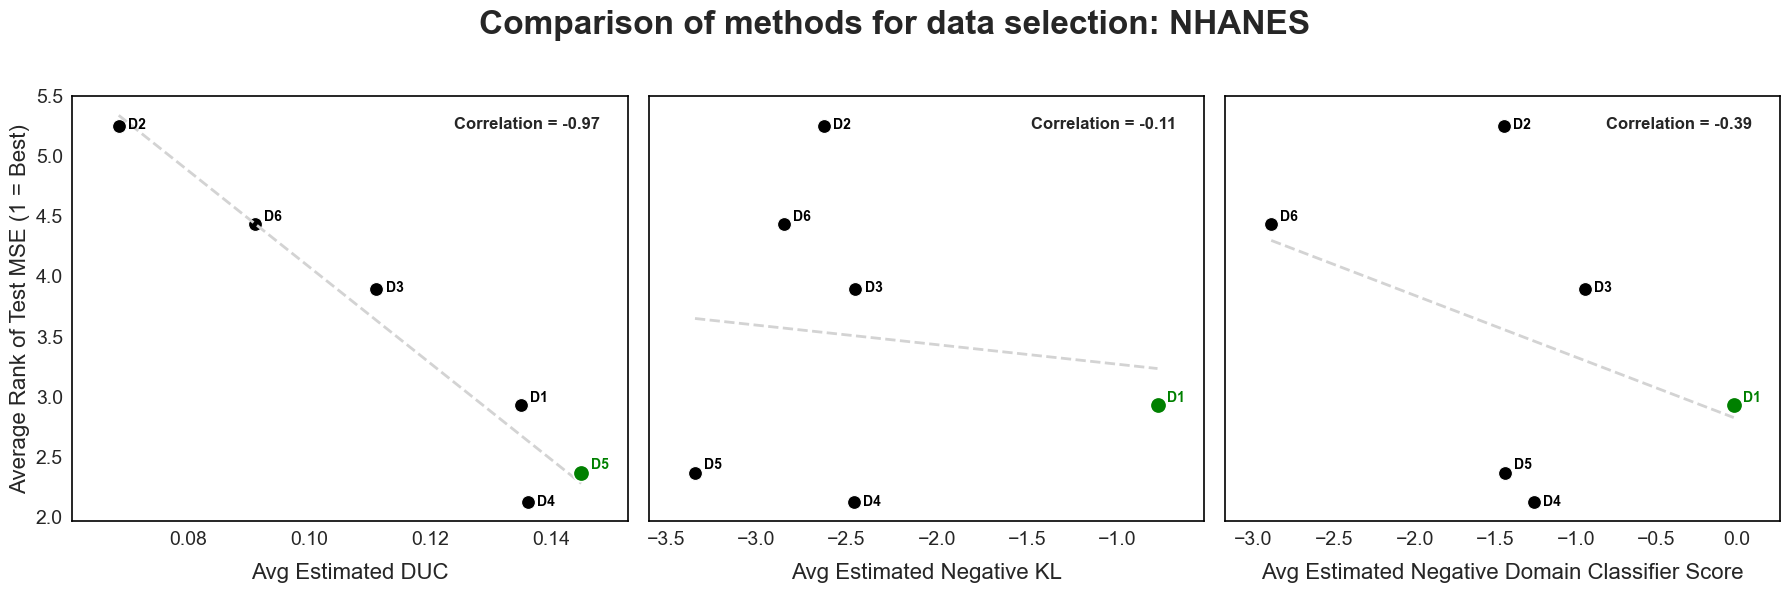

In [10]:
x_columns = ['duc', 'neg_kl', 'neg_score_x']
x_labels = [
    'Avg Estimated DUC',
    'Avg Estimated Negative KL',
    'Avg Estimated Negative Domain Classifier Score'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, facecolor='white')
axes = np.ravel(axes)

for ax, x_col, x_label in zip(axes, x_columns, x_labels):
    # Numeric views (for safety)
    x_num = pd.to_numeric(results_df[x_col], errors='coerce').astype(float)
    y_num = pd.to_numeric(results_df['avg_rank'], errors='coerce').astype(float)

    x_min, x_max = np.nanmin(x_num), np.nanmax(x_num)
    x_range = x_max - x_min if np.isfinite(x_min) and np.isfinite(x_max) else 1.0
    x_pad = 0.1 * (x_range if x_range > 0 else 1.0)

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Scatter of x vs avg rank
    sns.scatterplot(
        x=x_col,
        y='avg_rank',
        data=results_df,
        s=100,
        color='black',
        ax=ax,
        zorder=2
    )

    sns.regplot(
        x=x_col,
        y='avg_rank',
        data=results_df,
        scatter=False,
        ax=ax,
        ci=None,
        line_kws={'color': 'lightgrey', 'linestyle': '--', 'linewidth': 2}
    )

    if x_num.notna().any():
        max_label = x_num.idxmax()                             # index label of the max metric
        max_pos   = results_df.index.get_loc(max_label)        # convert to position
        ax.scatter(
            results_df.loc[max_label, x_col],
            results_df.loc[max_label, 'avg_rank'],
            s=140, color='green', edgecolor='white', linewidth=1.2, zorder=4
        )
    else:
        max_pos = -1  # nothing to highlight if all NaN

    # Pearson correlation (robust to NaNs/constant)
    mask = np.isfinite(x_num.values) & np.isfinite(y_num.values)
    if mask.sum() >= 3 and np.std(x_num.values[mask]) > 0 and np.std(y_num.values[mask]) > 0:
        pr = pearsonr(x_num.values[mask], y_num.values[mask])[0]
        corr_text = f'Correlation = {pr:.2f}'
    else:
        corr_text = 'Correlation = NA'
    ax.text(
        0.95, 0.95, corr_text,
        transform=ax.transAxes, fontsize=12, va='top', ha='right', weight='bold'
    )

    ax.set_xlabel(x_label, fontsize=16, labelpad=10)
    ax.set_facecolor('white')
    ax.grid(False)

    # Labels near points (green for highlighted max in THIS panel)
    for i in range(results_df.shape[0]):
        lbl_color = 'green' if i == max_pos else 'black'
        y_adjustment = 0.03 if (i % 2 == 0) else -0.03
        ax.text(
            results_df[x_col].iloc[i] + 0.02 * (x_range if x_range > 0 else 1.0),
            results_df['avg_rank'].iloc[i] + y_adjustment,
            results_df['label'].iloc[i],
            color=lbl_color, weight='semibold'
        )

    ax.set_xlim(x_min - x_pad, x_max + x_pad)

    # Style spines
    for spine in ['left', 'bottom', 'top', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.2)

axes[0].set_ylabel('Average Rank of Test MSE (1 = Best)', fontsize=16)
plt.suptitle('Comparison of methods for data selection: NHANES', fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()